# Softplus extension of the finite ring-attractor analysis

## Goal

Test how replacing the threshold-linear response function with
softplus changes:

1. Existence of bump fixed points
2. Local stability
3. Dependence of marginal tuning on JE and JI

## Current preliminary findings

- ReLU-tuned JE and JI collapse to a homogeneous fixed point state under the
  beta=2 softplus nonlinearity,instead of generating stable bump solution.
- Joint JE&JI parameter scan reveals a finite region containing stable bump
  candidates.
- Solving the fixed-point equations together with lambda_psi = 0
  gives a preliminary joint marginal-stability curve JE*(JI).

## Possible next steps

- Need to repeat for other N and several beta values.
- Need to compare velocity integration, zero-input drift, and noise
  sensitivity. Other possible property discoveries like limit cycles?

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import root
from scipy.special import expit

import ra_utilities as util #Still ReLu


importlib.reload(util)

<module 'ra_utilities' from '/Users/tinaguo/Desktop/Research/tina_neurocamp/ra_utilities.py'>

In [2]:
# Test 
print(util.preferred_headings(8))

[0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714]


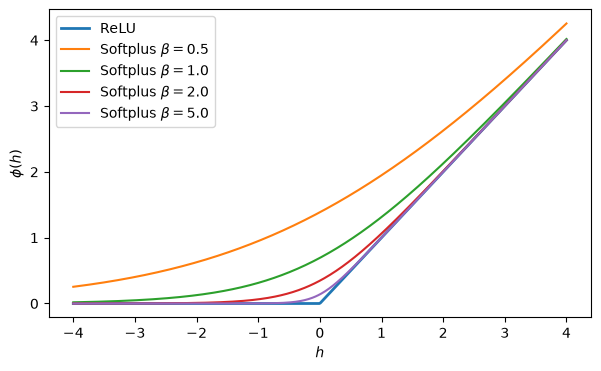

In [3]:
def relu(h):
    return np.maximum(h, 0.0)


def relu_prime(h):
    """Derivative of relu."""
    return (np.asarray(h) > 0.0).astype(float)


def softplus(h, beta=1.0):
    """Smooth approximation to ReLU."""
    h = np.asarray(h)
    return np.logaddexp(0.0, beta * h) / beta


def softplus_prime(h, beta=1.0):
    """Derivative of softplus."""
    return expit(beta * np.asarray(h))

# Plot to show the comparison between softplus and ReLU
x = np.linspace(-4, 4, 500)

plt.figure(figsize=(7, 4))
plt.plot(x, relu(x), label="ReLU", lw=2)

for beta in [0.5, 1.0, 2.0, 5.0]:
    plt.plot(
        x,
        softplus(x, beta=beta),
        label=fr"Softplus $\beta={beta}$"
    )

plt.xlabel(r"$h$")
plt.ylabel(r"$\phi(h)$")
plt.legend()
plt.show()

In [4]:
# Comparison : ReLU results from article:
N = 16
Nact = 8

theta = util.preferred_headings(N)

cff = 1.0
tau = 0.1
beta = 2.0

psi_preferred = theta[0]
psi_midpoint = 0.5 * (theta[0] + theta[1])

JE_relu = util.optimal_JE(N, Nact)
JI_relu = util.find_JI_for_amplitude(
    N,
    JE_relu,
    cff=cff,
    target_amplitude=0.2,
)

print("ReLU JE* =", JE_relu)
print("ReLU JI  =", JI_relu)

ReLU JE* = 4.0
ReLU JI  = -31.826036071777345


In [5]:
def rate_and_gain_projections(
    H0, a, psi, theta, phi, dphi
):
    """Compute the R and Q quantities of the reduced system."""

    delta = theta - psi
    cos_delta = np.cos(delta)
    sin_delta = np.sin(delta)

    # h_k = H0 + a cos(theta_k - psi)
    h = H0 + a * cos_delta

    # Firing rate and local nonlinear gain
    r = phi(h)
    gain = dphi(h)

    # Rate projections
    R0 = np.mean(r)
    Rc = np.mean(r * cos_delta)
    Rs = np.mean(r * sin_delta)

    # Gain-weighted moments/projections
    Q0 = np.mean(gain)
    Q1 = np.mean(gain * cos_delta)
    Q2 = np.mean(gain * cos_delta**2)
    Qs = np.mean(gain * sin_delta**2)

    return {
        "h": h,
        "r": r,
        "gain": gain,
        "R0": R0,
        "Rc": Rc,
        "Rs": Rs,
        "Q0": Q0,
        "Q1": Q1,
        "Q2": Q2,
        "Qs": Qs,
    }

In [6]:
#A test run: Assign softplus under phi definition
phi = lambda h: softplus(h, beta=beta)
dphi = lambda h: softplus_prime(h, beta=beta)
# Define R and Q params to simplify Equations and Jacobian computation later.
q = rate_and_gain_projections(
    H0=-0.5,
    a=1.0,
    psi=psi_preferred,
    theta=theta,
    phi=phi,
    dphi=dphi,
)

for name in ["R0", "Rc", "Rs", "Q0", "Q1", "Q2", "Qs"]:
    print(name, q[name])

print("Q0 - (Q2 + Qs) =", q["Q0"] - q["Q2"] - q["Qs"])
#check Q0 - (Q2 + Qs)=0; Rs = 0(approx): 

R0 0.25016929943115446
Rc 0.15290593598510058
Rs -2.0816681711721685e-17
Q0 0.33562494832166134
Q1 0.1773464789221055
Q2 0.18271900727497925
Qs 0.1529059410466821
Q0 - (Q2 + Qs) = 0.0


Given (JI,JE,phi)：

0= -H0+ JI* R0+ cff

0= −a+ JE* Rc
	​


In [7]:
def fixed_point_residual(
    x, JI, JE, cff, psi, theta, phi, dphi
):
    H0, a = x

    q = rate_and_gain_projections(
        H0, a, psi, theta, phi, dphi
    )

    F0 = -H0 + JI * q["R0"] + cff
    Fa = -a + JE * q["Rc"]

    return np.array([F0, Fa])

In [8]:
# Gain initial guess??? Still use ReLU params for initial softplus computation
def extract_reduced_coordinates(h, theta):
    """Extract H0, a, psi from a network input profile h."""
    h = np.asarray(h)
#Fourier computation
    H0 = np.mean(h)
    H1 = np.mean(h * np.exp(-1j * theta))

    a = 2.0 * np.abs(H1)
    psi = (-np.angle(H1)) % (2.0 * np.pi)

    return H0, a, psi

phi = lambda h: softplus(h, beta=beta)
dphi = lambda h: softplus_prime(h, beta=beta)

h_final = util.simulate_bump(
    N=N,
    JE=JE_relu,#Use RelU 
    JI=JI_relu,
    cff=cff,
    vin=0.0,
    tau=tau,
    t_max=10.0,
    psi0=psi_preferred,
    phi=phi,
    return_trajectory=False,
)

H0_guess, a_guess, psi_guess = extract_reduced_coordinates(
    h_final, theta
)

print("initial guess:")
print("H0 guess =", H0_guess)
print("a guess =", a_guess)
print("psi guess =", psi_guess)
# Relu parameter doesn't transfer directly to softplus, homogeneous fixed point result

initial guess:
H0 guess = -1.0042715296652451
a guess = 7.037806239332202e-17
psi guess = 4.2331606845053775


In [9]:
#scipy.optimize.root solve
solution = root(
    fixed_point_residual,
    x0=np.array([H0_guess, a_guess]),
    args=(
        JI_relu,
        JE_relu,
        cff,
        psi_preferred,
        theta,
        phi,
        dphi,
    ),
)

print("success:", solution.success)# convergence success
print("message:", solution.message)#standard:"The solution converged"
print("residual:", solution.fun)# input results back to function, should be approx 0

H0_star, a_star = solution.x

print("H0* =", H0_star)
print("a*  =", a_star)# a star is approx zero, not a bump fixed point solution,homogeneuos fixed point?

success: True
message: The solution converged.
residual: [ 0.00000000e+00 -3.08148791e-33]
H0* = -1.0041439296409407
a*  = -1.40710207720695e-17


In [10]:
# Calculate eigenvalues of the Jacobian
def reduced_eigenvalues(
    H0, a, psi, JI, JE, theta, phi, dphi, tau=1.0
):
    q = rate_and_gain_projections(
        H0, a, psi, theta, phi, dphi
    )

    Q0 = q["Q0"]
    Q1 = q["Q1"]
    Q2 = q["Q2"]
    Qs = q["Qs"]

    A = np.array([
        [-1.0 + JI * Q0, JI * Q1],
        [JE * Q1, -1.0 + JE * Q2],
    ])

    lambda_pm_dimensionless = np.linalg.eigvals(A)
    lambda_psi_dimensionless = -1.0 + JE * Qs

    return {
        "A": A,
        "lambda_pm": lambda_pm_dimensionless / tau,
        "lambda_psi": lambda_psi_dimensionless / tau,
        "quantities": q,
    }# Note:return a dictionary, use key to extract

In [11]:
# Use calculated eigenvalues from the dictionary(name:stability)
stability = reduced_eigenvalues(
    H0=H0_star,
    a=a_star,
    psi=psi_preferred,
    JI=JI_relu,
    JE=JE_relu,
    theta=theta,
    phi=phi,
    dphi=dphi,
    tau=tau,
)

print("A =")
print(stability["A"])

print("lambda_pm =", stability["lambda_pm"])
print("lambda_psi =", stability["lambda_psi"])

A =
[[-4.76614965e+00  2.35861414e-16]
 [-2.96438317e-17 -7.63329015e-01]]
lambda_pm = [-47.66149654+0.j  -7.63329015+0.j]
lambda_psi = -7.633290149458738


In [12]:
#Check if reduced eigenvalues is the same as the elements from full jacobian eigenvalue sets
def full_network_jacobian(
    h_star, N, JE, JI, tau, dphi
):
    W = util.symmetric_weights(N, JE, JI)
    gain = dphi(h_star)

    J = (
        -np.eye(N)
        + W * gain[None, :] / N#gain[None,:]--shape=(1, N)
    ) / tau

    return J

q_star = stability["quantities"]
h_star = q_star["h"]

J_full = full_network_jacobian(
    h_star=h_star,
    N=N,
    JE=JE_relu,
    JI=JI_relu,
    tau=tau,
    dphi=dphi,
)

eig_full = np.linalg.eigvals(J_full)
eig_full = eig_full[np.argsort(eig_full.real)[::-1]]# sort from max to min

print("largest full-network eigenvalues:")
print(eig_full[:])

print("H0_star =", H0_star)
print("a_star  =", a_star)

q = stability["quantities"]
#Printing these values out also comfirmed that we found homogeneous fixed points(h min=h max)
print("h range =", q["h"].min(), q["h"].max())
print("r range =", q["r"].min(), q["r"].max())

print("R0 =", q["R0"])
print("Rc =", q["Rc"])
print("Rs =", q["Rs"])

print("Q0 =", q["Q0"])
print("Q1 =", q["Q1"])
print("Q2 =", q["Q2"])
print("Qs =", q["Qs"])

largest full-network eigenvalues:
[ -7.63329015+0.j  -7.63329015+0.j -10.        +0.j -10.        +0.j
 -10.        +0.j -10.        +0.j -10.        +0.j -10.        +0.j
 -10.        +0.j -10.        +0.j -10.        +0.j -10.        +0.j
 -10.        +0.j -10.        +0.j -10.        +0.j -47.66149654+0.j]
H0_star = -1.0041439296409407
a_star  = -1.40710207720695e-17
h range = -1.0041439296409407 -1.0041439296409407
r range = 0.0629718361759218 0.0629718361759218
R0 = 0.0629718361759218
Rc = -3.517755193017376e-18
Rs = -1.6853219343333939e-19
Q0 = 0.11833549252706306
Q1 = -7.410957923342984e-18
Q2 = 0.05916774626353153
Qs = 0.05916774626353153


In [13]:
#This shows using JE JI value from ReLU result only found  homogeneous fixed points instead of a bump fixed point

In [14]:
JE_values = np.linspace(2.0, 15.0, 18)

JI_magnitude = abs(JI_relu)

JI_values = -np.linspace(
    0.05 * JI_magnitude,   #Weak inhibition
    1.5 * JI_magnitude,    # Stronger inhibition
    16,
)

print("JE range:", JE_values[0], JE_values[-1])
print("JI range:", JI_values[0], JI_values[-1])

JE range: 2.0 15.0
JI range: -1.5913018035888673 -47.73905410766602


In [15]:
#
a_map = np.full(
    (len(JI_values), len(JE_values)),
    np.nan,
)

steady_map = np.full_like(a_map, np.nan) #To store steady error

psi_target = theta[0]
h0_scan = -1.0 + 4.0 * np.cos(theta - psi_target) #Construct initial bump

for i, JI_test in enumerate(JI_values):
    for j, JE_test in enumerate(JE_values):
        try:
            t_test, h_test = util.simulate_bump(
                N=N,
                JE=JE_test,
                JI=JI_test,
                cff=cff,
                vin=0.0,# No velocity input for now
                tau=tau,
                t_max=20.0,
                dt=0.02,
                h0=h0_scan,
                phi=phi,
                return_trajectory=True,
                method="BDF",
            )

            h_final = h_test[-1]

            if not np.all(np.isfinite(h_final)):
                continue

            H0_final, a_final, psi_final = (
                extract_reduced_coordinates(
                    h_final, theta
                )
            )

            steady_error = np.max(
                np.abs(h_test[-1] - h_test[-10])
            )

        
            if np.max(np.abs(h_final)) < 100:
                a_map[i, j] = a_final
                steady_map[i, j] = steady_error

        except Exception:
            pass

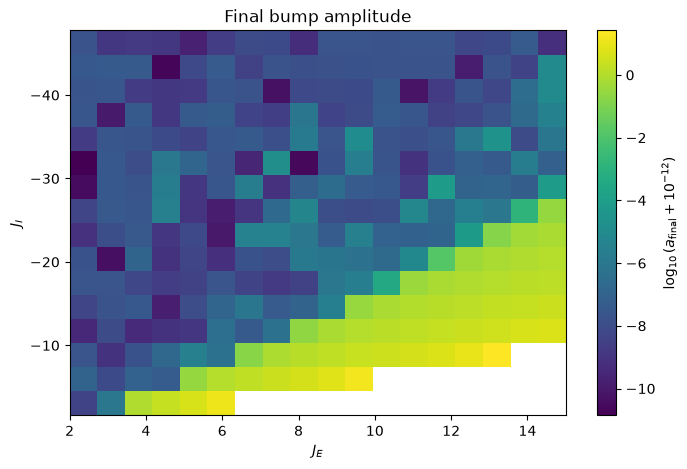

In [16]:
#Plot bump amplitude heatmap:
plt.figure(figsize=(8, 5))

plt.imshow(
    np.log10(a_map + 1e-12),
    origin="lower",
    aspect="auto",
    extent=[
        JE_values[0],
        JE_values[-1],
        JI_values[0],
        JI_values[-1],
    ],
    cmap="viridis",
)

plt.colorbar(label=r"$\log_{10}(a_{\mathrm{final}}+10^{-12})$")
plt.xlabel(r"$J_E$")
plt.ylabel(r"$J_I$")
plt.title("Final bump amplitude")
plt.show()


In [17]:
#The heatmap shows: Top left part (dark blue& purple):to much inhibition,a(bump amplitude) really small, means homogeneous state
#Central part: green, yellow strip:Balanced JE and JI: a>0 (Though doesn't necessarily means its more stable)

In [18]:
stable_bump_mask = (
    np.isfinite(a_map)
    & (a_map > 1e-2)
    & (steady_map < 1e-4)
)

print("number of candidate stable bumps:",
      np.sum(stable_bump_mask))


number of candidate stable bumps: 50


In [19]:
candidate_indices = np.argwhere(stable_bump_mask)

for i, j in candidate_indices[:20]:
    print(
        f"JE={JE_values[j]:.4f}, "
        f"JI={JI_values[i]:.4f}, "
        f"a={a_map[i, j]:.4f}, "
        f"steady_error={steady_map[i, j]:.2e}"
    )

JE=3.5294, JI=-1.5913, a=0.9190, steady_error=6.91e-08
JE=4.2941, JI=-1.5913, a=2.2486, steady_error=2.64e-06
JE=5.0588, JI=-1.5913, a=4.5242, steady_error=3.59e-07
JE=5.8235, JI=-1.5913, a=12.9288, steady_error=1.90e-05
JE=5.0588, JI=-4.6678, a=0.3081, steady_error=1.96e-05
JE=5.8235, JI=-4.6678, a=1.1142, steady_error=8.09e-10
JE=6.5882, JI=-4.6678, a=1.7820, steady_error=5.01e-08
JE=7.3529, JI=-4.6678, a=2.6386, steady_error=5.60e-09
JE=8.1176, JI=-4.6678, a=4.0051, steady_error=1.05e-07
JE=8.8824, JI=-4.6678, a=6.8089, steady_error=1.77e-07
JE=9.6471, JI=-4.6678, a=16.1931, steady_error=9.86e-07
JE=7.3529, JI=-7.7443, a=0.8401, steady_error=6.09e-06
JE=8.1176, JI=-7.7443, a=1.2859, steady_error=1.15e-07
JE=8.8824, JI=-7.7443, a=1.7514, steady_error=2.32e-08
JE=9.6471, JI=-7.7443, a=2.3114, steady_error=1.61e-07
JE=10.4118, JI=-7.7443, a=3.0615, steady_error=2.19e-07
JE=11.1765, JI=-7.7443, a=4.1839, steady_error=1.07e-07
JE=11.9412, JI=-7.7443, a=6.1096, steady_error=8.39e-08
JE=12

In [20]:
#choose: a=1.1274:JE=7.3529 JI=-7.7443 steady_error=3.14e-08 as our first numerical stimulation guess(bump amplitude medium, steady error low)
a=1.1274
JE_candidate=7.3529
JI_candidate=-7.7443
psi_target = theta[0]
h0_candidate = -1.0 + 4.0 * np.cos(
    theta - psi_target
)

t_candidate, h_candidate = util.simulate_bump(
    N=N,
    JE=JE_candidate,
    JI=JI_candidate,
    cff=cff,
    vin=0.0,
    tau=tau,
    t_max=50.0,
    dt=0.01,
    h0=h0_candidate,
    phi=phi,
    return_trajectory=True,
    method="BDF",
)

H0_guess, a_guess, psi_guess = (
    extract_reduced_coordinates(
        h_candidate[-1], theta
    )
)

print("H0_guess =", H0_guess)
print("a_guess =", a_guess)
print("psi_guess =", psi_guess)
print(
    "long-run steady error =",
    np.max(np.abs(
        h_candidate[-1] - h_candidate[-100]
    )),
)


H0_guess = -0.5684557009691302
a_guess = 0.8401105735741153
psi_guess = 1.7105718526754447e-09
long-run steady error = 1.1459559112747542e-06


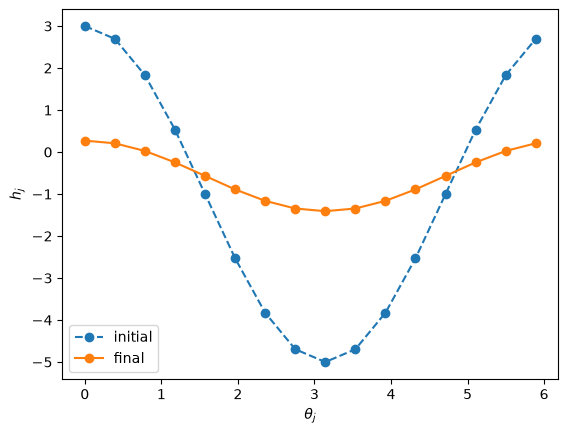

In [21]:
plt.plot(
    theta,
    h_candidate[0],
    "o--",
    label="initial",
)

plt.plot(
    theta,
    h_candidate[-1],
    "o-",
    label="final",
)

plt.xlabel(r"$\theta_j$")
plt.ylabel(r"$h_j$")
plt.legend()
plt.show()

In [22]:
#root-finding afterwards：
solution_bump = root(
    fixed_point_residual,
    x0=np.array([H0_guess, a_guess]),
    args=(
        JI_candidate,
        JE_candidate,
        cff,
        psi_target,
        theta,
        phi,
        dphi,
    ),
)

H0_bump, a_bump = solution_bump.x

print("success =", solution_bump.success)
print("message =", solution_bump.message)
print("residual =", solution_bump.fun)
print(
    "residual norm =",
    np.linalg.norm(solution_bump.fun),
)
print("H0_bump =", H0_bump)
print("a_bump =", a_bump)
#Valid bump check:
valid_bump = (
    solution_bump.success
    and np.linalg.norm(solution_bump.fun) < 1e-8
    and a_bump > 1e-4
)

print("valid bump fixed point =", valid_bump)
#Rs check:
q_bump = rate_and_gain_projections(
    H0_bump,
    a_bump,
    psi_target,
    theta,
    phi,
    dphi,
)

print("R0 =", q_bump["R0"])
print("Rc =", q_bump["Rc"])
print("Rs =", q_bump["Rs"])

success = True
message = The solution converged.
residual = [ 2.22044605e-16 -1.11022302e-16]
residual norm = 2.482534153247273e-16
H0_bump = -0.5684560197266142
a_bump = 0.8401116140238891
valid bump fixed point = True
R0 = 0.20253037972787907
Rc = 0.11425581933983721
Rs = -6.938893903907228e-18


In [23]:
#Calculate Eigenvalues:
stability_bump = reduced_eigenvalues(
    H0=H0_bump,
    a=a_bump,
    psi=psi_target,
    JI=JI_candidate,
    JE=JE_candidate,
    theta=theta,
    phi=phi,
    dphi=dphi,
    tau=tau,
)

print("A =")
print(stability_bump["A"])

print(
    "lambda_pm =",
    stability_bump["lambda_pm"],
)

print(
    "lambda_psi =",
    stability_bump["lambda_psi"],
)

A =
[[-3.3025061  -1.1377006 ]
 [ 1.08020076  0.18613653]]
lambda_pm = [-29.04925966+0.j  -2.11443613+0.j]
lambda_psi = 4.8677919473050224e-08


In [24]:

def marginal_fixed_point_residual(
    y,
    JI,
    cff,
    psi,
    theta,
    phi,
    dphi,
):
    """
    Unknowns:
        y = [H0, a, JE]

    Equations:
        H0 fixed-point condition
        a fixed-point condition
        lambda_psi = 0
    """
    H0, a, JE = y

    q = rate_and_gain_projections(
        H0,
        a,
        psi,
        theta,
        phi,
        dphi,
    )

    return np.array([
        -H0 + JI * q["R0"] + cff,
        -a + JE * q["Rc"],
        -1.0 + JE * q["Qs"],
    ])


In [25]:
optimal_solution = root(
    marginal_fixed_point_residual,
    x0=np.array([
        H0_bump,
        a_bump,
        JE_candidate,
    ]),
    args=(
        JI_candidate,
        cff,
        psi_target,
        theta,
        phi,
        dphi,
    ),
)

H0_opt, a_opt, JE_opt = optimal_solution.x

print("success =", optimal_solution.success)
print("message =", optimal_solution.message)
print("residual =", optimal_solution.fun)
print(
    "residual norm =",
    np.linalg.norm(optimal_solution.fun),
)

print("H0_opt =", H0_opt)
print("a_opt =", a_opt)
print("JE_opt =", JE_opt)
print("JI_fixed =", JI_candidate)

success = False
message = The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
residual = [ 4.00618427e-11 -2.39449816e-09  2.01097916e-09]
residual norm = 3.127181407097087e-09
H0_opt = -0.5684254035198392
a_opt = 0.8400227383098455
JE_opt = 7.352755308125103
JI_fixed = -7.7443


In [26]:
optimal_stability = reduced_eigenvalues(
    H0=H0_opt,
    a=a_opt,
    psi=psi_target,
    JI=JI_candidate,
    JE=JE_opt,
    theta=theta,
    phi=phi,
    dphi=dphi,
    tau=tau,
)

print(
    "lambda_pm =",
    optimal_stability["lambda_pm"],
)

print(
    "lambda_psi =",
    optimal_stability["lambda_psi"],
)
valid_optimal_bump = (
    optimal_solution.success
    and np.linalg.norm(optimal_solution.fun) < 1e-8
    and a_opt > 1e-4
    and np.max(
        optimal_stability["lambda_pm"].real
    ) < 0
    and abs(
        optimal_stability["lambda_psi"]
    ) < 1e-6
)

print(
    "valid marginally stable bump =",
    valid_optimal_bump,
)

lambda_pm = [-29.05001576+0.j  -2.11411326+0.j]
lambda_psi = 2.0109791609712602e-08
valid marginally stable bump = False


In [27]:

residual_norm = np.linalg.norm(
    optimal_solution.fun
)

checks = {
    "solver_success":
        optimal_solution.success,

    "small_residual":
        residual_norm < 1e-8,

    "nonzero_bump":
        a_opt > 1e-4,

    "positive_JE":
        JE_opt > 0,

    "even_directions_stable":
        np.max(
            optimal_stability["lambda_pm"].real
        ) < 0,

    "orientation_marginal":
        abs(
            optimal_stability["lambda_psi"]
        ) < 1e-6,
}

for name, passed in checks.items():
    print(name, ":", passed)

print("residual norm =", residual_norm)
print("a_opt =", a_opt)
print("JE_opt =", JE_opt)

solver_success : False
small_residual : True
nonzero_bump : True
positive_JE : True
even_directions_stable : True
orientation_marginal : True
residual norm = 3.127181407097087e-09
a_opt = 0.8400227383098455
JE_opt = 7.352755308125103


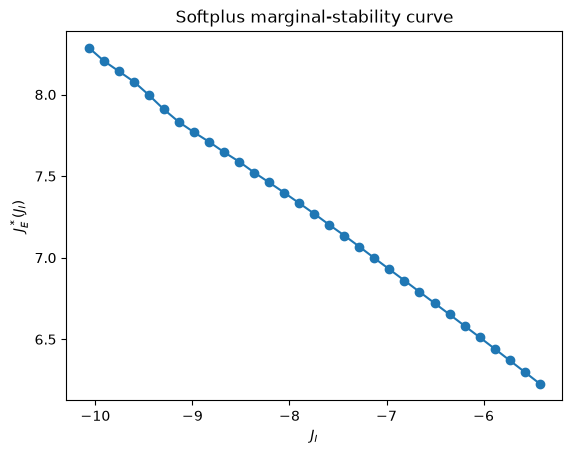

In [28]:
JI_curve_values = np.linspace(
    0.7 * JI_candidate,
    1.3 * JI_candidate,
    31,
)

curve_records = []


y_previous = np.array([
    H0_opt,
    a_opt,
    JE_opt,
])

for JI_test in JI_curve_values:
    sol = root(
        marginal_fixed_point_residual,
        x0=y_previous,
        args=(
            JI_test,
            cff,
            psi_target,
            theta,
            phi,
            dphi,
        ),
    )

    H0_test, a_test, JE_test = sol.x
    residual_norm = np.linalg.norm(sol.fun)

    acceptable_solution = (
    np.all(np.isfinite(sol.x))
    and residual_norm < 1e-7
    and a_test > 1e-4
    and JE_test > 0
)

    if not acceptable_solution:
        curve_records.append([
            JI_test,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        ])
        continue

        curve_records.append([
            JI_test,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
         ])
        continue

    stability_test = reduced_eigenvalues(
        H0=H0_test,
        a=a_test,
        psi=psi_target,
        JI=JI_test,
        JE=JE_test,
        theta=theta,
        phi=phi,
        dphi=dphi,
        tau=tau,
    )

    lambda_even_max = np.max(
        stability_test["lambda_pm"].real
    )

    curve_records.append([
        JI_test,
        JE_test,
        H0_test,
        a_test,
        lambda_even_max,
    ])

    # continuation
    y_previous = sol.x.copy()

curve_records = np.asarray(curve_records)
valid = (
    np.isfinite(curve_records[:, 1])
    & (curve_records[:, 4] < 0)
)

plt.plot(
    curve_records[valid, 0],
    curve_records[valid, 1],
    "o-",
)

plt.xlabel(r"$J_I$")
plt.ylabel(r"$J_E^*(J_I)$")
plt.title("Softplus marginal-stability curve")
plt.show()

In [29]:
#Run Test
diagnostics = []

for row in curve_records[valid]:
    JI_test, JE_test, H0_test, a_test, lambda_even_max = row

    residual = marginal_fixed_point_residual(
        [H0_test, a_test, JE_test],
        JI_test,
        cff,
        psi_target,
        theta,
        phi,
        dphi,
    )

    stability_test = reduced_eigenvalues(
        H0=H0_test,
        a=a_test,
        psi=psi_target,
        JI=JI_test,
        JE=JE_test,
        theta=theta,
        phi=phi,
        dphi=dphi,
        tau=tau,
    )

    diagnostics.append([
        JI_test,
        JE_test,
        H0_test,
        a_test,
        np.linalg.norm(residual),
        stability_test["lambda_psi"],
        np.max(
            stability_test["lambda_pm"].real
        ),
    ])

diagnostics = np.asarray(diagnostics)

print(
    "maximum residual norm =",
    np.max(diagnostics[:, 4]),
)

print(
    "maximum |lambda_psi| =",
    np.max(np.abs(diagnostics[:, 5])),
)

print(
    "largest lambda_pm over curve =",
    np.max(diagnostics[:, 6]),
)

print(
    "minimum bump amplitude =",
    np.min(diagnostics[:, 3]),
)

maximum residual norm = 2.644993367225118e-08
maximum |lambda_psi| = 1.9033179698979552e-07
largest lambda_pm over curve = -1.4628123996361708
minimum bump amplitude = 0.6371559753796562
